In [1]:
!sudo apt-get update -y
!sudo apt-get install python3.10 python3.10-dev python3.10-venv –y

!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 1
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.12 2
!sudo update-alternatives --config python3

!sudo apt-get install python3-pip -y
!python3 -m pip install --upgrade pip

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,328 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:11 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 https://ppa.launchpadcontent.net/graphics-driver

In [2]:
!pip install opencv-python \
matplotlib \
numpy \
pandas \
seaborn \
scikit-learn \
Pillow \
tensorflow \
openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 51.0 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 98.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 97.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 120.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 109.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 110.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.4/620.4 MB 22.0 MB/s  0:00:15
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 101.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 74.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 91.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 86.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 93.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
from pathlib import Path
import shutil
from abc import ABCMeta, abstractmethod
from typing import Optional
from collections import Counter, defaultdict
from random import sample
import re

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
import cv2


In [16]:
# %%
class Config:
    # Project paths
    try:
        import google.colab
        PROJECT_ROOT = Path('/content/drive/MyDrive/Colab Notebooks')
        CACHE_DIR = Path("/content/cache")
        TRAINING_PATH = "/content/training"
        VALIDATION_PATH = "/content/validation"
    except ImportError:
        if '__file__' in locals() or '__file__' in globals():
            PROJECT_ROOT = Path(__file__).parent.resolve()
        else:
            PROJECT_ROOT = Path(os.getcwd())

        CACHE_DIR = Path(f"{PROJECT_ROOT}/cache/odir5k_ensemble_classification")
        TRAINING_PATH = "training"
        VALIDATION_PATH = "validation"

    DATASET_DIR = PROJECT_ROOT / "ODIR-5K"

    # Dataset configuration
    ANNOTATION_FILE_NAME = 'ODIR-5K_Training_Annotations(Updated)_V2.xlsx'
    TRAINING_SOURCE_PATH = 'ODIR-5K_Training_Images'
    TESTING_SOURCE_PATH = 'ODIR-5K_Testing_Images'
    LABELS = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
    VALIDATION_FRACTION = 0.1

    # Image processing
    TARGET_SIZE = (512, 512)
    COLOR_MODE = 'rgb'
    COLOR_SHAPE_MAP = {'grayscale': (1,), 'rgb': (3,), 'rgba': (4,)}
    SHAPE_ADD = COLOR_SHAPE_MAP.get(COLOR_MODE, (3,))

    # Model configuration
    BATCH_SIZE = 32
    EPOCHS = 30
    LEARNING_RATE = 1e-5

    # Loss functions
    LOSS = {
        'output_odir5kmcc': 'categorical_crossentropy',
        'output_odir5kmlc': 'binary_crossentropy',
    }
    OPTIMIZER = tf.keras.optimizers.Adam(LEARNING_RATE)

    # Metrics
    METRICS = {
        'output_odir5kmcc': [
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(multi_label=True, num_labels=len(config.LABELS), name='auc')
        ],
        'output_odir5kmlc': [
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(multi_label=True, num_labels=len(config.LABELS), name='auc')
        ],
    }

    # Model paths
    MODEL_DIR = PROJECT_ROOT / "Trained_Models" / "ODIR-5K-Ensemble-Classification"
    MODEL_SAVE_WEIGHTS = str(MODEL_DIR / 'ODIR5K_weights.weights.h5')
    MODEL_SAVE_FINAL = str(MODEL_DIR / 'ODIR5K_final.keras')
    CHECKPOINT_PATH = str(MODEL_DIR / 'ODIR5K.keras')

    CHECKPOINT_PATH_ODIR5k_MCC = str(PROJECT_ROOT / "Trained_Models" / "ODIR5K-Multi-Class" / "ODIR5K.keras")
    CHECKPOINT_PATH_ODIR5k_MLC = str(PROJECT_ROOT / "Trained_Models" / "ODIR5K-Multi-Label" / "ODIR5K.keras")

config = Config()


In [9]:
os.chdir(config.DATASET_DIR)
df = pd.read_excel(config.ANNOTATION_FILE_NAME)


In [10]:
left_eye_keywords = df['Left-Diagnostic Keywords'].copy()
right_eye_keywords = df['Right-Diagnostic Keywords'].copy()

left_eye_keywords = left_eye_keywords.str.split(re.compile(r'[,，]'))
right_eye_keywords = right_eye_keywords.str.split(re.compile(r'[,，]'))

labels_dict = defaultdict(Counter)
all_diagostic_keywords = [[] for _ in range(len(config.LABELS))]
keyword_label_map = {}

for _, row in df.iterrows():
    keywords = []
    for col in ["Left-Diagnostic Keywords", "Right-Diagnostic Keywords"]:
        if isinstance(row[col], str):
            kws = re.split(r'[,，]', row[col])
            keywords.extend([kw.strip() for kw in kws if kw.strip()])

    vec = row[config.LABELS].to_numpy()
    active_idx = np.where(vec == 1)[0]

    for kw in keywords:
        for i in active_idx:
            lab = config.LABELS[i]
            labels_dict[lab][kw] += 1

        counts = [labels_dict[config.LABELS[i]][kw] for i in active_idx]
        best_idx = active_idx[np.argmax(counts)]
        best_lab = config.LABELS[best_idx]

        if kw not in keyword_label_map or labels_dict[best_lab][kw] > labels_dict[config.LABELS[keyword_label_map[kw]]][kw]:
            if kw in keyword_label_map:
                old_label_index = keyword_label_map[kw]
                if kw in all_diagostic_keywords[old_label_index]:
                    all_diagostic_keywords[old_label_index].remove(kw)

            keyword_label_map[kw] = best_idx
            all_diagostic_keywords[best_idx].append(kw)

all_diagostic_keywords = [list(set(keywords)) for keywords in all_diagostic_keywords]


In [11]:
# Function for generate label to single image

# Return index in key of all diagnosis list
def get_index_label(key, all_key):
    return next((i for i, keywords in enumerate(all_key) if key in keywords), -1)

# Return multilabel by index
def get_multi_label_from_keys(label_idxs):
    return [1 if i in label_idxs else 0 for i in range(len(config.LABELS))]

def extract_fundus_dataset():
    def process_fundus_entry(filename, keywords, all_key):
        img_path = os.path.join(config.TRAINING_SOURCE_PATH, filename)
        label = get_fundus_multi_label(img_path, keywords, all_key)
        return img_path, label

    def get_fundus_multi_label(img_path, keywords, all_key):
        if not os.path.exists(img_path):
            return None

        # generate multi-label
        indices = [get_index_label(key, all_key) for key in keywords]
        indices = list(set(indices))
        label = get_multi_label_from_keys(indices)

        return label

    paths, labels = [], []

    for col, keywords in [('Left-Fundus', left_eye_keywords), ('Right-Fundus', right_eye_keywords)]:
        for filename, keywords in zip(df[col], keywords):
            path, label = process_fundus_entry(filename, keywords, all_diagostic_keywords)
            if label: paths.append(path); labels.append(label)

    return np.array(paths), np.array(labels)

synthetic_paths, synthetic_labels = extract_fundus_dataset()

# Grouping by patient ID to prevent data leakage
groups = [os.path.basename(p).split('_')[0] for p in synthetic_paths]

gss = GroupShuffleSplit(n_splits=1, test_size=config.VALIDATION_FRACTION, random_state=1)
train_idx, val_idx = next(gss.split(synthetic_paths, synthetic_labels, groups=groups))

training_paths = synthetic_paths[train_idx]
training_labels = synthetic_labels[train_idx]

validation_paths = synthetic_paths[val_idx]
validation_labels = synthetic_labels[val_idx]

print("n training samples:", len(training_paths))
print("n validation samples:", len(validation_paths))

del synthetic_paths
del synthetic_labels


n training samples: 6300
n validation samples: 700


In [12]:
# caching data
def _get_raw_cached_dataset(self: tf.data.Dataset, name) -> tf.data.Dataset:
    cache_dir = config.CACHE_DIR / '_get_raw_cached_dataset'
    cache_dir.mkdir(parents=True, exist_ok=True)

    for lockfile in cache_dir.glob("*.lockfile"):
        try: lockfile.unlink(missing_ok=True)
        except Exception: pass

    cache_path = str(cache_dir / f"{name}.cache")
    self = self.cache(cache_path)

    # warmup cache
    if not (cache_dir / f"{name}.cache").exists():
        self.enumerate().reduce(np.int64(0), lambda x, _: x + 1)

    return self

# oversampling data
def get_balanced_dataset(self, num_samples, num_classes=8):
    class_datasets = []
    for i in range(num_classes):
        class_ds = self.filter(lambda x, y: tf.argmax(y['output_odir5kmcc']) == i).repeat()
        class_datasets.append(class_ds)

    balanced_ds = tf.data.Dataset.sample_from_datasets(
        class_datasets,
        weights=[1.0/num_classes] * num_classes
    )
    return balanced_ds.take(num_samples)

# extension methods
tf.data.Dataset._get_raw_cached_dataset = _get_raw_cached_dataset

def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    return image

def resize_image(image):
    image = tf.image.resize_with_pad(
        image, config.TARGET_SIZE[0],
        config.TARGET_SIZE[1],
        method=tf.image.ResizeMethod.BILINEAR
    )
    image.set_shape([config.TARGET_SIZE[0], config.TARGET_SIZE[1], 3])
    return image

def crop_image(image):
    mask = tf.reduce_sum(image, axis=-1) > 10
    non_zero_coords = tf.where(mask)

    if tf.shape(non_zero_coords)[0] == 0:
        return image

    y_min = tf.cast(tf.reduce_min(non_zero_coords[:, 0]), tf.int32)
    y_max = tf.cast(tf.reduce_max(non_zero_coords[:, 0]), tf.int32)
    x_min = tf.cast(tf.reduce_min(non_zero_coords[:, 1]), tf.int32)
    x_max = tf.cast(tf.reduce_max(non_zero_coords[:, 1]), tf.int32)

    image = tf.image.crop_to_bounding_box(image, y_min, x_min, y_max - y_min + 1, x_max - x_min + 1)
    return image

def CLAHE(image):
    # uint8 format (0-255)
    image = tf.cast(image, tf.uint8)
    image_shape = image.shape

    # input numpy array
    image = tf.numpy_function(func=clahe_cv2, inp=[image], Tout=tf.uint8)

    # Reset shape
    image.set_shape(image_shape)
    return image

def clahe_cv2(image):
    # input numpy array
    if not isinstance(image, np.ndarray):
        image = np.array(image)

    # RGB to LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE to the L-channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    # Merge channels + convert back to RGB
    lab = cv2.merge((l, a, b))
    image_res = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return image_res

def get_random_label_from_multilabel(multi_labels):
    return np.array([
        np.random.choice(np.where(row == 1)[0]) if np.any(row == 1) else 0
        for row in multi_labels
    ])

indices_mc_random = get_random_label_from_multilabel(training_labels)
training_labels_mcc = tf.keras.utils.to_categorical(indices_mc_random, num_classes=len(config.LABELS))
training_labels_mlc = training_labels

indices_mc_random_val = get_random_label_from_multilabel(validation_labels)
validation_labels_mcc = tf.keras.utils.to_categorical(indices_mc_random_val, num_classes=len(config.LABELS))
validation_labels_mlc = validation_labels

raw_train_ds = tf.data.Dataset.from_tensor_slices((
    training_paths,
    {
        'output_odir5kmcc': training_labels_mcc,
        'output_odir5kmlc': training_labels_mlc,
    }
))
raw_val_ds = tf.data.Dataset.from_tensor_slices((
    validation_paths, {
        'output_odir5kmcc': validation_labels_mcc,
        'output_odir5kmlc': validation_labels_mlc,
    }
))

train_ds_generator = (
    raw_train_ds
    .shuffle(len(training_paths))
    .apply(lambda ds: get_balanced_dataset(ds, len(training_paths), num_classes=8))
    .map(lambda path, lbl: (load_image(path), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (crop_image(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (resize_image(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (CLAHE(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    ._get_raw_cached_dataset(name="training")
    .shuffle(buffer_size=1000)
    .batch(config.BATCH_SIZE, drop_remainder=False)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

validation_ds_generator = (
    raw_val_ds
    .map(lambda path, lbl: (load_image(path), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (crop_image(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (resize_image(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda img, lbl: (CLAHE(img), lbl), num_parallel_calls=tf.data.AUTOTUNE)
    ._get_raw_cached_dataset(name="validation")
    .batch(config.BATCH_SIZE, drop_remainder=False)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)


In [13]:
model_odir5kmcc = tf.keras.models.load_model(config.CHECKPOINT_PATH_ODIR5k_MCC)
model_odir5kmlc = tf.keras.models.load_model(config.CHECKPOINT_PATH_ODIR5k_MLC)

backbone_odir5kmcc = tf.keras.Model(
    inputs=model_odir5kmcc.inputs,
    outputs=model_odir5kmcc.layers[-5].output,
    name="backbone_mcc"
)
backbone_odir5kmcc.trainable = False

backbone_odir5kmlc = tf.keras.Model(
    inputs=model_odir5kmlc.inputs,
    outputs=model_odir5kmlc.layers[-8].output,
    name="backbone_mlc"
)
backbone_odir5kmlc.trainable = False

inputs = tf.keras.layers.Input(shape=config.TARGET_SIZE + config.SHAPE_ADD)

feat_odir5kmcc = backbone_odir5kmcc(inputs)
feat_odir5kmlc = backbone_odir5kmlc(inputs)

dim_mcc = backbone_odir5kmcc.output_shape[-1]
dim_mlc = backbone_odir5kmlc.output_shape[-1]

query = tf.keras.layers.Reshape((1, dim_mcc))(feat_odir5kmcc)
value = tf.keras.layers.Reshape((1, dim_mlc))(feat_odir5kmlc)

output_attention = tf.keras.layers.MultiHeadAttention(num_heads=4, key_dim=dim_mcc)(query=query, value=value)
output_attention = tf.keras.layers.LayerNormalization()(output_attention)
output_attention = tf.keras.layers.Flatten()(output_attention)

feat_odir5kmcc_ln = tf.keras.layers.LayerNormalization()(feat_odir5kmcc)
feat_odir5kmlc_ln = tf.keras.layers.LayerNormalization()(feat_odir5kmlc)

feat_merged = tf.keras.layers.Concatenate()([feat_odir5kmcc_ln, feat_odir5kmlc_ln, output_attention])

x = tf.keras.layers.Dense(512, activation='swish')(feat_merged)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)

output_odir5kmcc = tf.keras.layers.Dense(8, activation='softmax', name='output_odir5kmcc')(x)
output_odir5kmlc = tf.keras.layers.Dense(8, activation='sigmoid', name='output_odir5kmlc')(x)

model = tf.keras.models.Model(inputs=inputs, outputs=[output_odir5kmcc, output_odir5kmlc])

model.summary(line_length=100)


Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 512, 512, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ backbone_mcc (Functional)   │ (None, 256)             │      1,174,176 │ input_layer[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ backbone_mlc (Functional)   │ (None, 256)             │      1,214,016 │ input_layer[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ reshape (Reshape)           │ (None, 1, 256)          │              0 │ backbone_mcc[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ reshape_1 (Reshape)         │ (None, 1, 256)          │              0 │ backbone_mlc[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ multi_head_attention        │ (None, 1, 256)          │      1,051,904 │ reshape[0][0],          │
│ (MultiHeadAttention)        │                         │                │ reshape_1[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ layer_normalization         │ (None, 1, 256)          │            512 │ multi_head_attention[0… │
│ (LayerNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ layer_normalization_1       │ (None, 256)             │            512 │ backbone_mcc[0][0]      │
│ (LayerNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ layer_normalization_2       │ (None, 256)             │            512 │ backbone_mlc[0][0]      │
│ (LayerNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ flatten (Flatten)           │ (None, 256)             │              0 │ layer_normalization[0]… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ concatenate (Concatenate)   │ (None, 768)             │              0 │ layer_normalization_1[… │
│                             │                         │                │ layer_normalization_2[… │
│                             │                         │                │ flatten[0][0]           │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dense (Dense)               │ (None, 512)             │        393,728 │ concatenate[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ batch_normalization         │ (None, 512)             │          2,048 │ dense[0][0]             │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ dropout_1 (Dropout)         │ (None, 512)             │              0 │ batch_normalization[0]… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ output_odir5kmcc (Dense)    │ (None, 8)               │          4,104 │ dropout_1[0][0]         │
├─────────────────────────────┼─────────────────────────┼────

 Total params: 3,845,616 (14.67 MB)

 Trainable params: 1,456,400 (5.56 MB)

 Non-trainable params: 2,389,216 (9.11 MB)

In [17]:
class TaskWeightScheduler(tf.keras.callbacks.Callback):
    """
    Implements Dynamic Weight Averaging (DWA) to balance task losses.
    Based on: https://arxiv.org/abs/1803.10704
    """
    def __init__(self, task_names, initial_weights=None, temperature=2.0):
        super(TaskWeightScheduler, self).__init__()
        self.task_names = task_names
        self.temperature = temperature
        self.loss_history = {name: [] for name in task_names}

        self.task_weights = {}
        for name in task_names:
            val = initial_weights[name] if initial_weights and name in initial_weights else 1.0
            self.task_weights[name] = tf.Variable(
                val, trainable=False, dtype=tf.float32, name=f"weight_{name}"
            )

    def on_epoch_end(self, epoch, logs=None):
        # 1. Update loss history
        for name in self.task_names:
            loss_val = logs.get(f"{name}_loss")
            if loss_val is not None:
                self.loss_history[name].append(loss_val)

        # 2. DWA after the first epoch (at least 2 epochs of loss)
        if epoch >= 1 and all(len(h) >= 2 for h in self.loss_history.values()):
            rs = []
            for name in self.task_names:
                r = self.loss_history[name][-1] / (self.loss_history[name][-2] + 1e-8)
                rs.append(r)

            rs = np.array(rs)
            exp_rs = np.exp(rs / self.temperature)
            new_weights = (len(self.task_names) * exp_rs) / np.sum(exp_rs)

            print(f"\n--- Epoch {epoch+1}: DWA updated task weights ---")
            for i, name in enumerate(self.task_names):
                self.task_weights[name].assign(new_weights[i])
                print(f"  - {name}: {float(new_weights[i]):.4f}")

initial_task_weights = {
    'output_odir5kmcc': 0.3,
    'output_odir5kmlc': 0.7,
}
weight_scheduler = TaskWeightScheduler(
    task_names=['output_odir5kmcc', 'output_odir5kmlc'],
    initial_weights=initial_task_weights
)

model.compile(
    loss=config.LOSS,
    optimizer=config.OPTIMIZER,
    metrics=config.METRICS,
    loss_weights=weight_scheduler.task_weights
)

In [18]:
import gc
gc.collect()

config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

callbacks = [
    weight_scheduler,
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(config.CHECKPOINT_PATH, monitor='val_output_odir5kmcc_accuracy', save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history = model.fit(
    train_ds_generator,
    validation_data=validation_ds_generator,
    epochs=config.EPOCHS,
    verbose=1,
    callbacks=callbacks
)


Epoch 1/30
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - loss: 1.0749 - output_odir5kmcc_accuracy: 0.3894 - output_odir5kmcc_auc: 0.7596 - output_odir5kmcc_loss: 1.8335 - output_odir5kmcc_precision: 0.5348 - output_odir5kmcc_recall: 0.2815 - output_odir5kmlc_accuracy: 0.5927 - output_odir5kmlc_auc: 0.6880 - output_odir5kmlc_loss: 0.7497 - output_odir5kmlc_precision: 0.2113 - output_odir5kmlc_recall: 0.6843
Epoch 1: val_output_odir5kmcc_accuracy improved from -inf to 0.21429, saving model to /content/drive/MyDrive/Colab Notebooks/Trained_Models/ODIR-5K-Ensemble-Classification/ODIR5K.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 119s 536ms/step - loss: 1.0748 - output_odir5kmcc_accuracy: 0.3894 - output_odir5kmcc_auc: 0.7596 - output_odir5kmcc_loss: 1.8334 - output_odir5kmcc_precision: 0.5349 - output_odir5kmcc_recall: 0.2815 - output_odir5kmlc_accuracy: 0.5927 - output_odir5kmlc_auc: 0.6880 - output_odir5kmlc_loss: 0.7497 - output_odir5kmlc_precision: 0.2113 - output_odir5kmlc_recall: 0.6843 - val_

In [19]:
model.save_weights(config.MODEL_SAVE_WEIGHTS)
model.save(config.MODEL_SAVE_FINAL)


In [20]:
model.evaluate(validation_ds_generator)


22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 427ms/step - loss: 2.7106 - output_odir5kmcc_accuracy: 0.1943 - output_odir5kmcc_auc: 0.7262 - output_odir5kmcc_loss: 2.0532 - output_odir5kmcc_precision: 0.2735 - output_odir5kmcc_recall: 0.0799 - output_odir5kmlc_accuracy: 0.6041 - output_odir5kmlc_auc: 0.6856 - output_odir5kmlc_loss: 0.6590 - output_odir5kmlc_precision: 0.2067 - output_odir5kmlc_recall: 0.6358


[2.685457468032837,
 2.025550603866577,
 0.660230278968811,
 0.2142857164144516,
 0.7412877082824707,
 0.28921568393707275,
 0.08428571373224258,
 0.6044642925262451,
 0.6979205012321472,
 0.20041494071483612,
 0.6264591217041016]

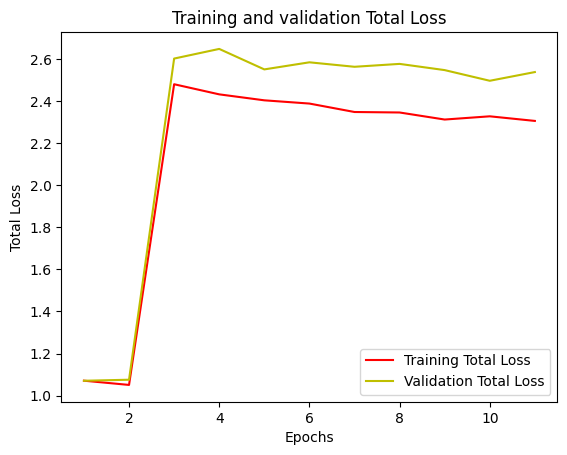

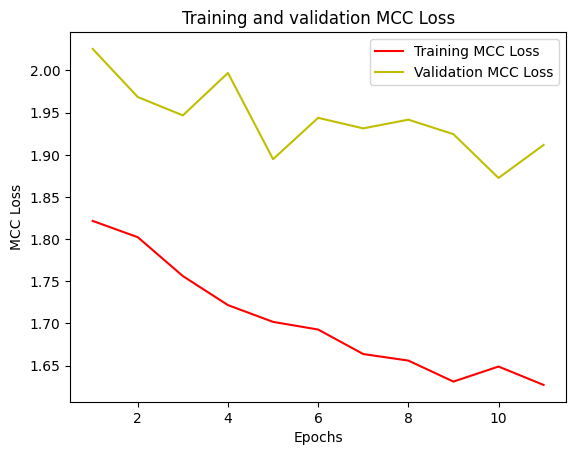

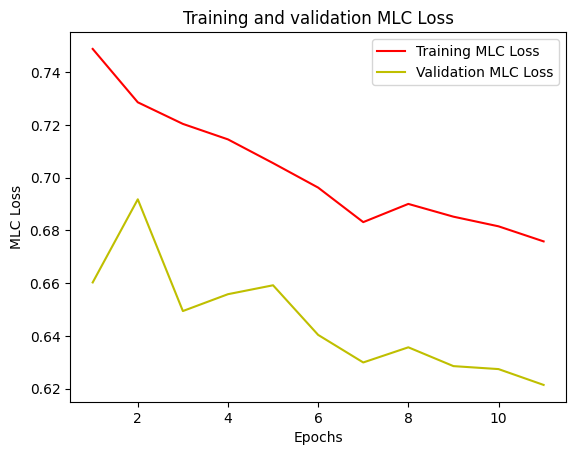

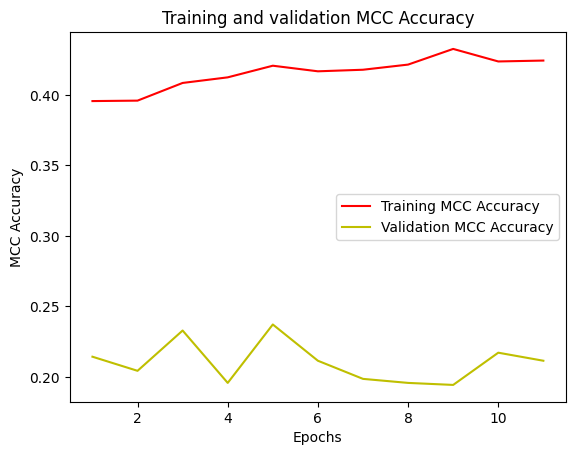

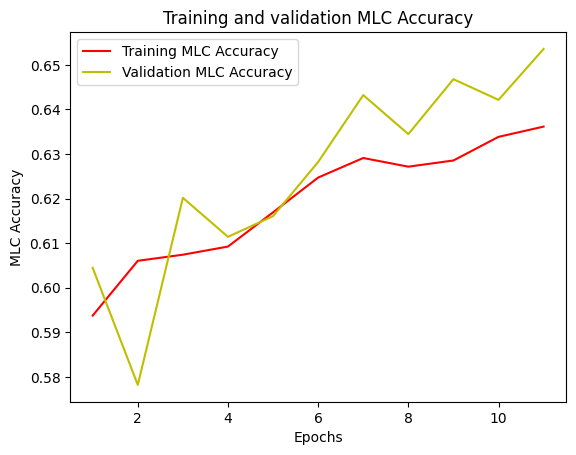

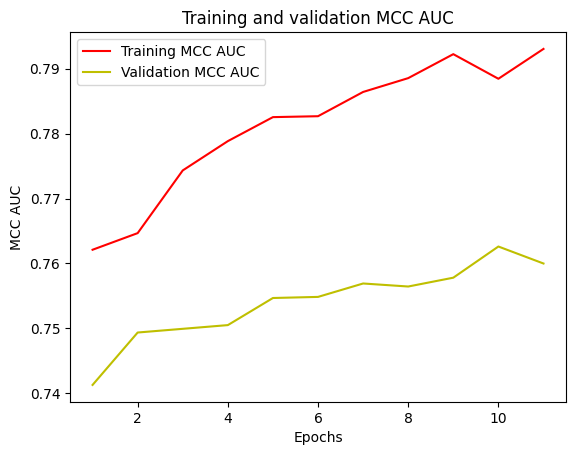

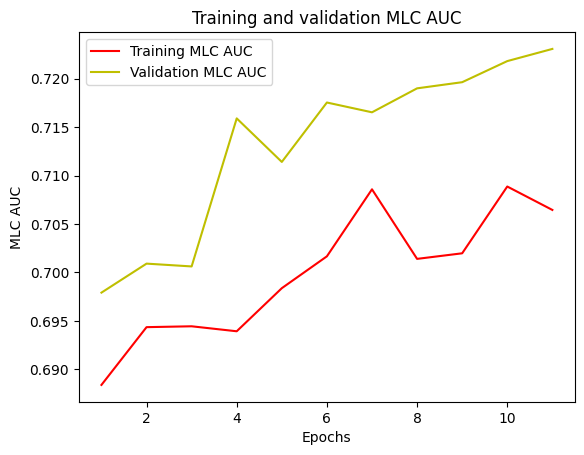

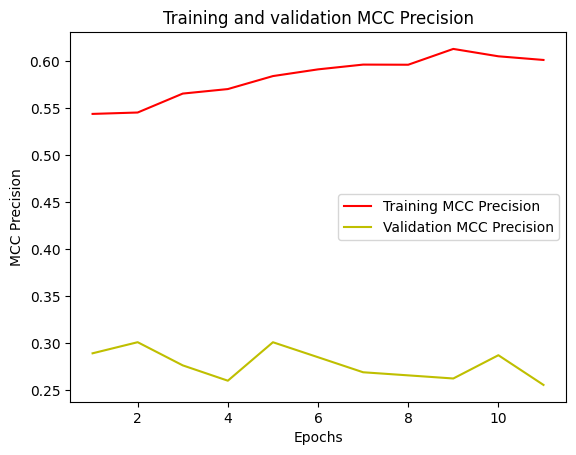

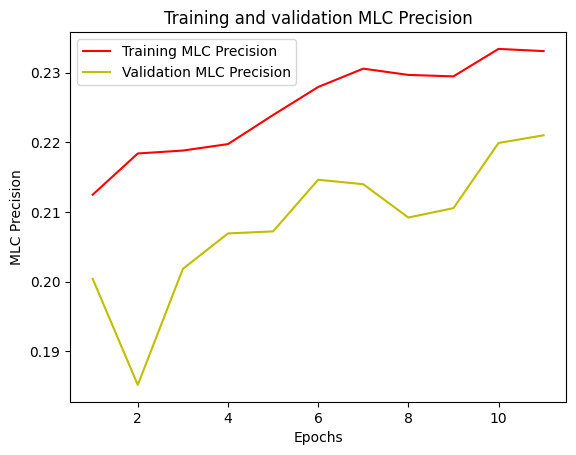

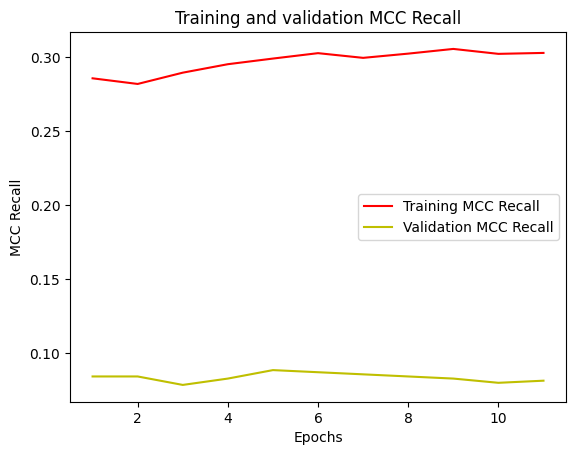

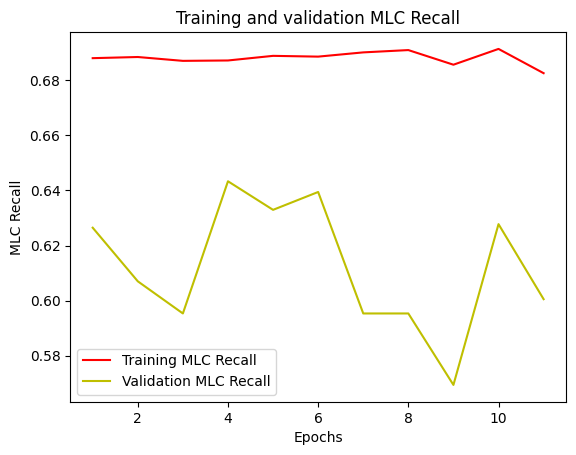

In [21]:
metrics = [
    ('loss', 'Total Loss'),
    ('output_odir5kmcc_loss', 'MCC Loss'),
    ('output_odir5kmlc_loss', 'MLC Loss'),
    ('output_odir5kmcc_accuracy', 'MCC Accuracy'),
    ('output_odir5kmlc_accuracy', 'MLC Accuracy'),
    ('output_odir5kmcc_auc', 'MCC AUC'),
    ('output_odir5kmlc_auc', 'MLC AUC'),
    ('output_odir5kmcc_precision', 'MCC Precision'),
    ('output_odir5kmlc_precision', 'MLC Precision'),
    ('output_odir5kmcc_recall', 'MCC Recall'),
    ('output_odir5kmlc_recall', 'MLC Recall'),
]
epochs = range(1, len(history.history['loss']) + 1)
for key, label in metrics:
    if key in history.history:
        plt.figure()
        plt.plot(epochs, history.history[key], 'r', label=f'Training {label}')
        if f'val_{key}' in history.history:
            plt.plot(epochs, history.history[f'val_{key}'], 'y', label=f'Validation {label}')
        plt.title(f'Training and validation {label}')
        plt.legend()
        plt.xlabel('Epochs')
        plt.ylabel(label)
plt.show()


In [22]:
test_files = sorted([f for f in os.listdir(config.TESTING_SOURCE_PATH) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
print(f"\nTotal testing images found: {len(test_files)}")

# header
print(f"\n{'File Name':<25} | {'MCC Prediction':<20} | {'MLC Active Labels':<40}")
print("-" * 90)

for i in range(len(test_files)):
    img_path = os.path.join(config.TESTING_SOURCE_PATH, test_files[i])

    # preprocess
    img = load_image(img_path)
    img = crop_image(img)
    img = resize_image(img)
    img = CLAHE(img)
    img = tf.cast(img, tf.float32)

    img_batch = tf.expand_dims(img, axis=0)

    # predict
    preds = model.predict(img_batch, verbose=0)
    # preds[0] -> output_odir5kmcc (Softmax - 8)
    # preds[1] -> output_odir5kmlc (Sigmoid - 8)

    # process MCC (Single class)
    mcc_idx = np.argmax(preds[0][0])
    mcc_label = config.LABELS[mcc_idx]

    # process MLC (Multiple labels)
    mlc_probs = preds[1][0]
    active_labels = [config.LABELS[j] for j, prob in enumerate(mlc_probs) if prob >= 0.5]
    mlc_label_str = ", ".join(active_labels) if active_labels else "None"

    print(f"{test_files[i]:<25} | {mcc_label:<20} | {mlc_label_str:<40}")



Total testing images found: 1000

File Name                 | MCC Prediction       | MLC Active Labels                       
------------------------------------------------------------------------------------------
1000_left.jpg             | G                    | N, D, G, A                              
1000_right.jpg            | G                    | N, D, G, A                              
1001_left.jpg             | D                    | D                                       
1001_right.jpg            | H                    | C                                       
1002_left.jpg             | H                    | D, A, H                                 
1002_right.jpg            | H                    | D, H                                    
1003_left.jpg             | M                    | D, A, M, O                              
1003_right.jpg            | M                    | D, A, M, O                              
1004_left.jpg             | D                 